In [4]:
using Pkg
Pkg.activate(".")
using GLMakie, BenchmarkTools, Random, Plots


include("struktury.jl")
include("logika_symulacji.jl")
include("kalibracja.jl")

  Activating project at `c:\Users\Tusiaczek\Desktop\obliczenia naukowe\repo`


Struktury załadowane.
Moduł kalibracji załadowany.


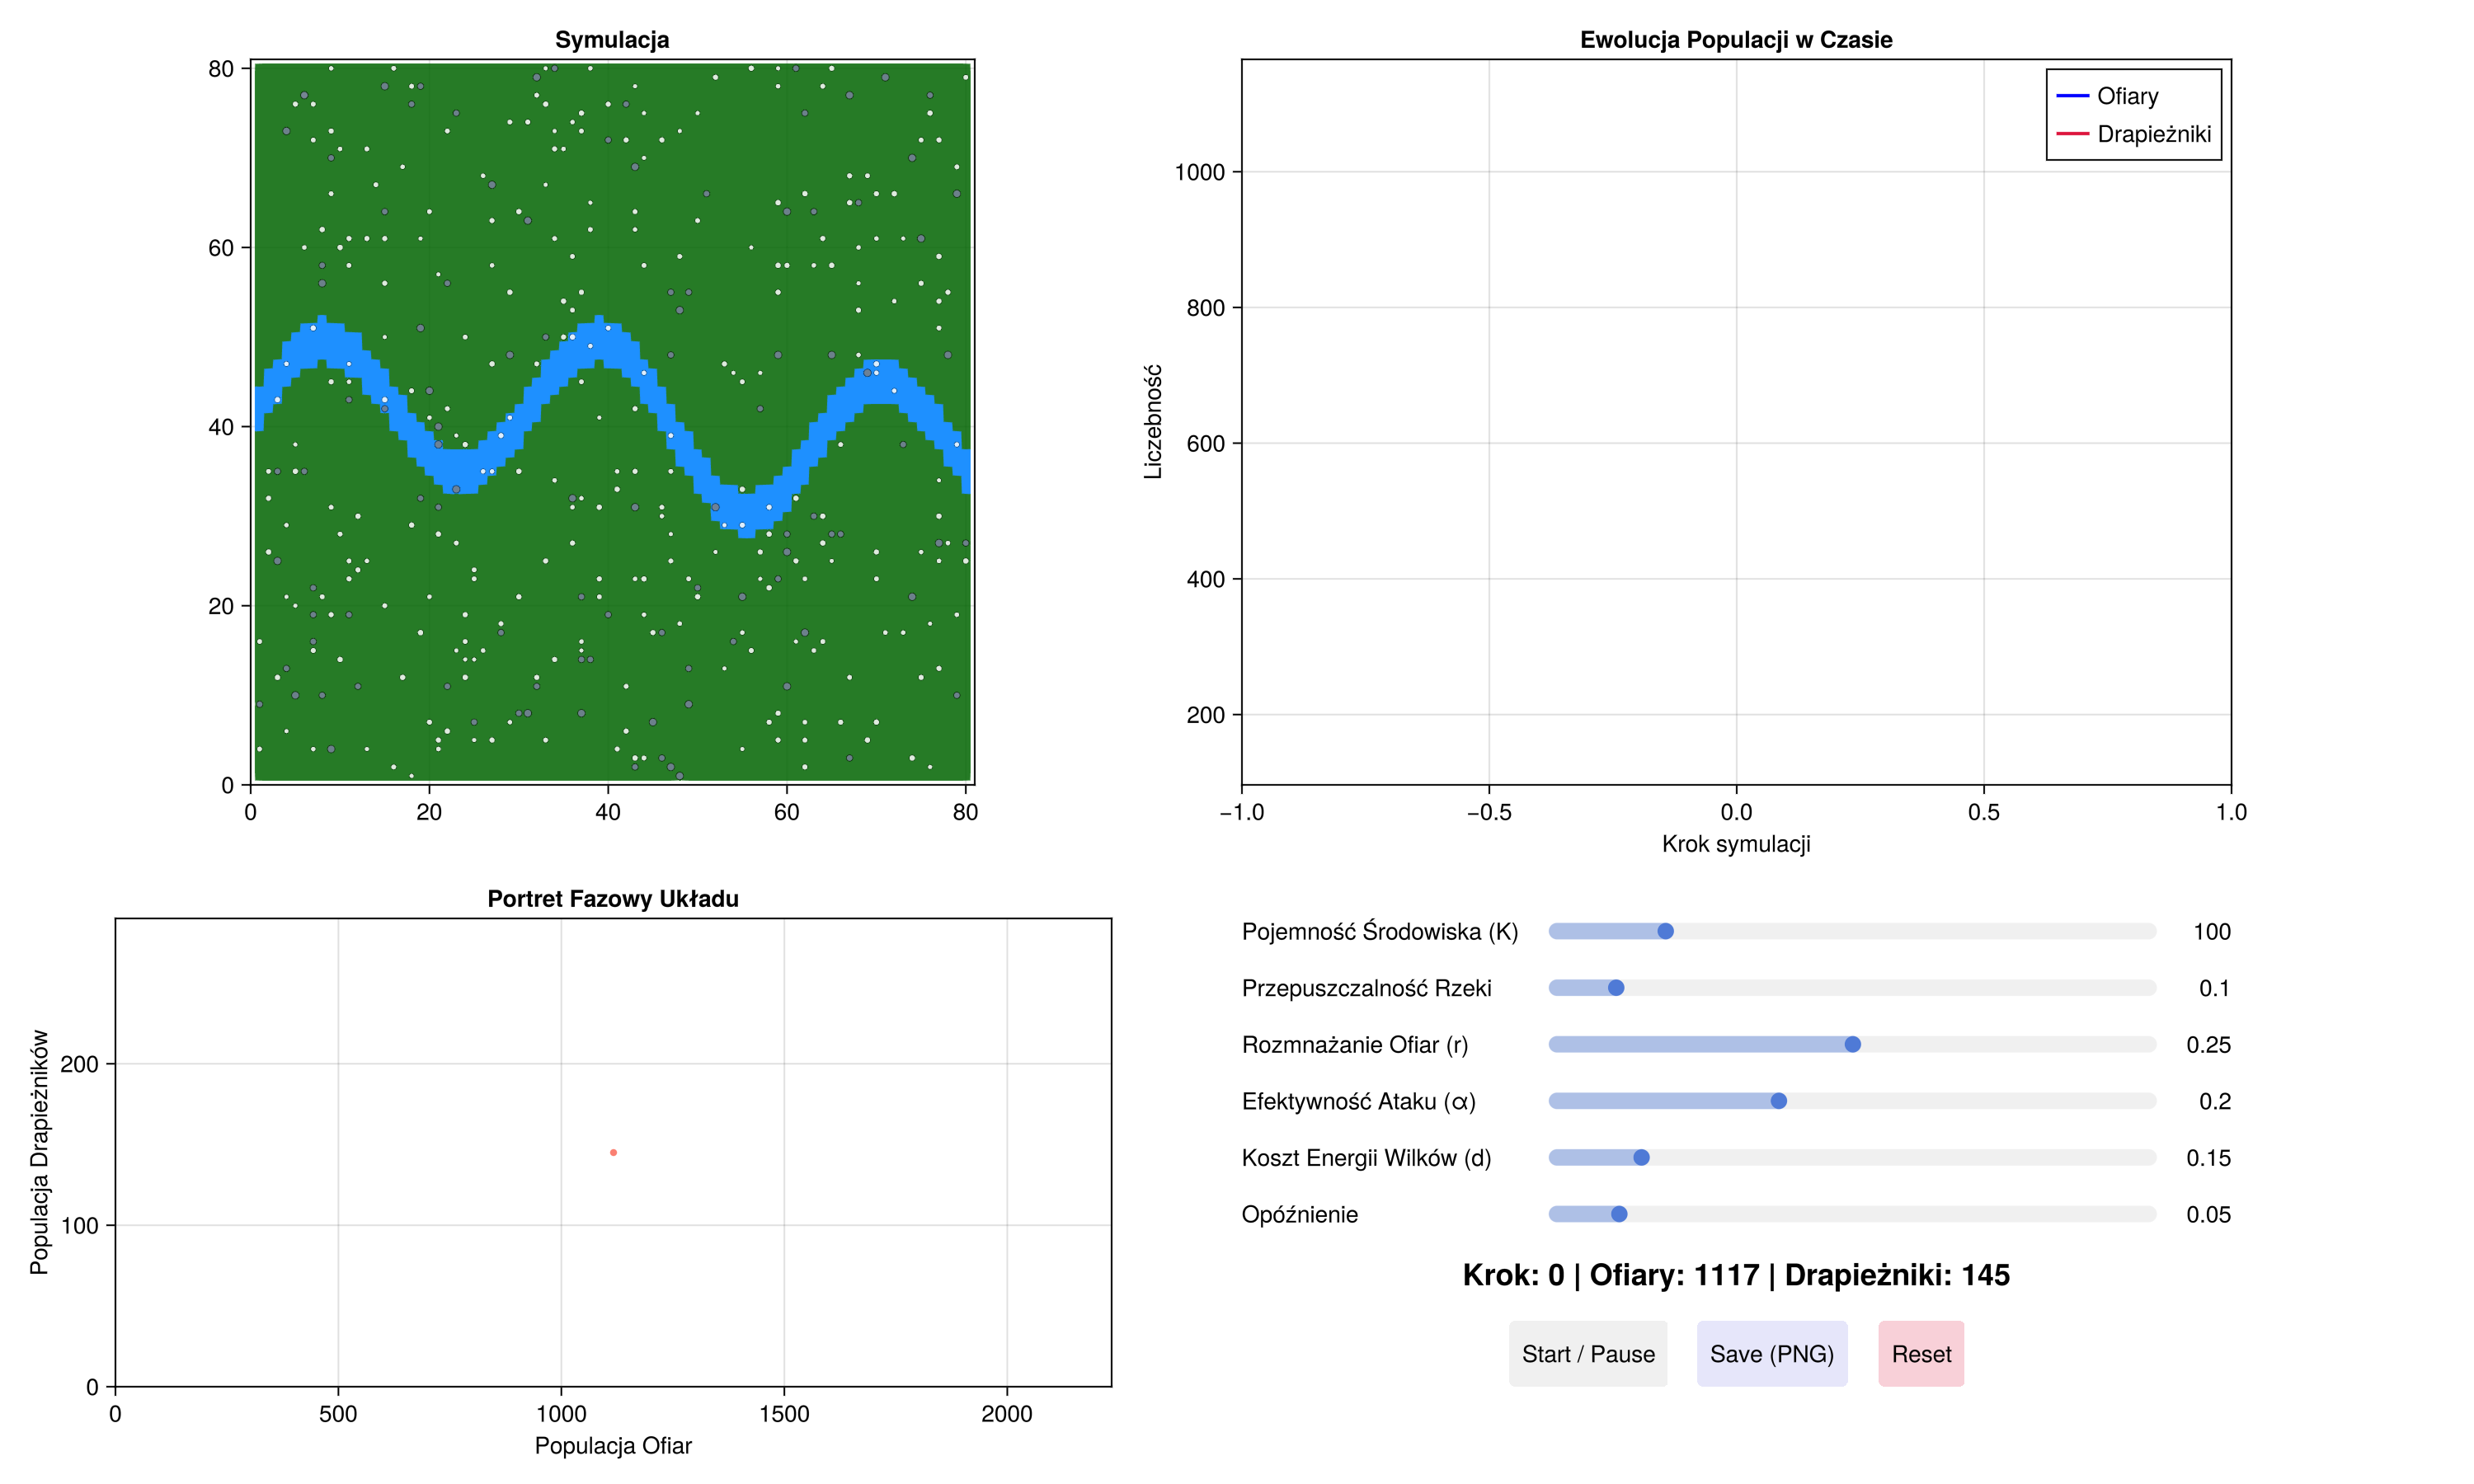

In [5]:
#interfejs z symulatorem
GLMakie.activate!()

NewGridSize = 80

terrain_map = zeros(Int64, NewGridSize, NewGridSize)
for i in 1:NewGridSize
    center_j = NewGridSize/2 + sin(i/5)*8 + sin(i/15)*3
    for offset in -2:2
        river_j = clamp(round(Int, center_j + offset), 1, NewGridSize)
        terrain_map[i, river_j] = 1
    end
end
Random.seed!(42)#dla powtarzalności losowań, można to zakomentarzować i będzie za każdym razem inna liczba O/D
init_prey = zeros(Int64, NewGridSize, NewGridSize)
init_pred = zeros(Int64, NewGridSize, NewGridSize)
init_energy = zeros(Float64, NewGridSize, NewGridSize)

for j in 1:NewGridSize, i in 1:NewGridSize
    if rand() < 0.04  
        init_prey[i, j] = rand(2:6) 
    end
    if rand() < 0.015 
        init_pred[i, j] = rand(1:2)
        init_energy[i, j] = 0.5
    end
end

current_state = GridState(init_prey, init_pred, init_energy, terrain_map)
next_state = GridState(zeros(Int64, NewGridSize, NewGridSize), zeros(Int64, NewGridSize, NewGridSize), zeros(Float64, NewGridSize, NewGridSize), terrain_map)

prey_obs = Observable(Float64.(current_state.prey))
pred_obs = Observable(Float64.(current_state.pred))

history_points_time_prey = Observable(Point2f[(0.0, sum(current_state.prey))])
history_points_time_pred = Observable(Point2f[(0.0, sum(current_state.pred))])
history_points_phase     = Observable(Point2f[(sum(current_state.prey), sum(current_state.pred))])

stats_text = Observable("Krok: 0 | Ofiary: $(Int(sum(current_state.prey))) | Drapieżniki: $(Int(sum(current_state.pred)))")

fig = Figure(size = (1500, 900))

# Główna mapa
ax_map = Axis(fig[1, 1], title = "Symulacja", aspect = DataAspect())
GLMakie.heatmap!(ax_map, 1:NewGridSize, 1:NewGridSize, terrain_map, colormap = [(:darkgreen, 0.85), :dodgerblue], colorrange = (0,1))
limits!(ax_map, 0, NewGridSize+1, 0, NewGridSize+1)

points = [Point2f(j, i) for i in 1:NewGridSize for j in 1:NewGridSize]

prey_sizes = lift(p -> vec([val > 0 ? (val^0.3 * 2.2 + 1.0) : 0.0 for val in p]), prey_obs)
pred_sizes = lift(p -> vec([val > 0 ? (val^0.35 * 3.5 + 1.5) : 0.0 for val in p]), pred_obs)

GLMakie.scatter!(ax_map, points, marker = :circle, markersize = prey_sizes, color = (:white, 0.85), strokecolor = :black, strokewidth = 0.2)
GLMakie.scatter!(ax_map, points, marker = :circle, markersize = pred_sizes, color = (:slategrey, 0.95), strokecolor = :black, strokewidth = 0.3)

# Wykres czasowy
ax_lines = Axis(fig[1, 2], title = "Ewolucja Populacji w Czasie", xlabel = "Krok symulacji", ylabel = "Liczebność")
lines!(ax_lines, history_points_time_prey, color = :blue, linewidth = 2, label = "Ofiary")
lines!(ax_lines, history_points_time_pred, color = :crimson, linewidth = 2, label = "Drapieżniki")
axislegend(ax_lines, position = :rt)

# Wykres fazowy
ax_phase = Axis(fig[2, 1], title = "Portret Fazowy Układu", xlabel = "Populacja Ofiar", ylabel = "Populacja Drapieżników")
lines!(ax_phase, history_points_phase, color = :purple, linewidth = 1.5)
GLMakie.scatter!(ax_phase, lift(p -> [p[end]], history_points_phase), color = :salmon, markersize = 6)

# Panel sterowania
controls_layout = GridLayout(fig[2, 2])
sg = SliderGrid(
    controls_layout[1, 1],
    (label = "Pojemność Środowiska (K)", range = 10:10:500, startvalue = 100),
    (label = "Przepuszczalność Rzeki", range = 0.0:0.05:1, startvalue = 0.1),
    (label = "Rozmnażanie Ofiar (r)", range = 0.05:0.01:0.45, startvalue = 0.25),
    (label = "Efektywność Ataku (α)", range = 0.05:0.01:0.45, startvalue = 0.20),
    (label = "Koszt Energii Wilków (d)", range = 0.10:0.01:0.45, startvalue = 0.15),
    (label = "Opóźnienie", range = 0.01:0.02:0.4, startvalue = 0.06),
    width = 600
)

Label(controls_layout[2, 1], stats_text, fontsize = 18, font = :bold, halign = :center)

buttons_layout = GridLayout(controls_layout[3, 1])
btn_run = Button(buttons_layout[1, 1], label = "Start / Pause", height = 40)
btn_save = Button(buttons_layout[1, 2], label = "Save (PNG)", height = 40, buttoncolor = :lavender)
btn_reset = Button(buttons_layout[1, 3], label = "Reset", height = 40, buttoncolor = (:crimson, 0.2)) 

is_running = Observable(false)
on(btn_run.clicks) do _ is_running[] = !is_running[] end

on(btn_save.clicks) do _
    filename = "symulator_krok_$(step_counter).png"
    save(filename, fig)
end

on(btn_reset.clicks) do _
    # 1. Zatrzymujemy symulację, jeśli leciała w tle
    is_running[] = false
    
    # 2. Resetujemy licznik kroków w zasięgu globalnym
    global step_counter = 0
    
    # 3. Generujemy świeże tablice początkowe (tak jak na starcie programu)
    Random.seed!(42)
    new_init_prey = zeros(Int64, NewGridSize, NewGridSize)
    new_init_pred = zeros(Int64, NewGridSize, NewGridSize)
    new_init_energy = zeros(Float64, NewGridSize, NewGridSize)

    for j in 1:NewGridSize, i in 1:NewGridSize
        if rand() < 0.04  
            new_init_prey[i, j] = rand(2:6) 
        end
        if rand() < 0.015 
            new_init_pred[i, j] = rand(1:2)
            new_init_energy[i, j] = 0.5
        end
    end
    
    # 4. Nadpisujemy stan symulatora
    global current_state = GridState(new_init_prey, new_init_pred, new_init_energy, terrain_map)
    global next_state = GridState(zeros(Int64, NewGridSize, NewGridSize), zeros(Int64, NewGridSize, NewGridSize), zeros(Float64, NewGridSize, NewGridSize), terrain_map)
    
    # 5. Aktualizujemy widok mapy 
    prey_obs[] = Float64.(current_state.prey)
    pred_obs[] = Float64.(current_state.pred)
    
    # 6. Czyścimy wykresy liniowe i fazowe do punktu zero
    history_points_time_prey[] = Point2f[(0.0, sum(current_state.prey))]
    history_points_time_pred[] = Point2f[(0.0, sum(current_state.pred))]
    history_points_phase[]     = Point2f[(sum(current_state.prey), sum(current_state.pred))]
    
    # 7. Resetujemy napisy informacyjne
    stats_text[] = "Krok: 0 | Ofiary: $(Int(sum(current_state.prey))) | Drapieżniki: $(Int(sum(current_state.pred)))"
    
    # 8. Resetujemy skale osi wykresów, by dopasowały się do punktu startowego
    autolimits!(ax_lines)
    autolimits!(ax_phase)
    
    println("Symulator został zresetowany!")
end

step_counter = 0
@async while true
    if is_running[]
        p = SimParams(
            sg.sliders[1].value[], sg.sliders[2].value[],
            sg.sliders[3].value[], sg.sliders[4].value[],
            sg.sliders[5].value[]
        )
        
        update_sim!(next_state, current_state, p)
        global current_state, next_state
        temp = current_state; current_state = next_state; next_state = temp
        global step_counter += 1
        
        s_prey = sum(current_state.prey)
        s_pred = sum(current_state.pred)
        
        prey_obs[] = Float64.(current_state.prey)
        pred_obs[] = Float64.(current_state.pred)
        
        stats_text[] = "Krok: $step_counter | Ofiary: $s_prey | Drapieżniki: $s_pred"
        
        arr_tp = history_points_time_prey[]
        arr_td = history_points_time_pred[]
        arr_ph = history_points_phase[]
        
        push!(arr_tp, Point2f(step_counter, s_prey))
        push!(arr_td, Point2f(step_counter, s_pred))
        push!(arr_ph, Point2f(s_prey, s_pred))
        
        if length(arr_tp) > 1000
            deleteat!(arr_tp, 1)
            deleteat!(arr_td, 1)
        end
        
        history_points_time_prey[] = arr_tp
        history_points_time_pred[] = arr_td
        history_points_phase[]     = arr_ph
        
        autolimits!(ax_lines)
        autolimits!(ax_phase)
    end
    sleep(sg.sliders[6].value[])
end

fig

In [3]:
#sprawdzenie alokacji
N_bench = 80
c_b = GridState(rand(0:1, N_bench, N_bench), rand(0:1, N_bench, N_bench), zeros(Float64, N_bench, N_bench), zeros(Int64, N_bench, N_bench))
n_b = GridState(zeros(Int64, N_bench, N_bench), zeros(Int64, N_bench, N_bench), zeros(Float64, N_bench, N_bench), zeros(Int64, N_bench, N_bench))
p_b = SimParams(150, 0.2, 0.05, 0.01, 0.1)

# Oczekiwany wynik: skrajnie niski czas wykonania oraz zero alokacji (0 allocations: 0 bytes)
@btime update_sim!($n_b, $c_b, $p_b)

  442.800 μs (0 allocations: 0 bytes)


Zoptymalizowany błąd: 0.0
Prawidłowe parametry [r, K, α, b, d]: [0.25, 25600.0, 3.125e-5, 2.34375e-5, 0.08]


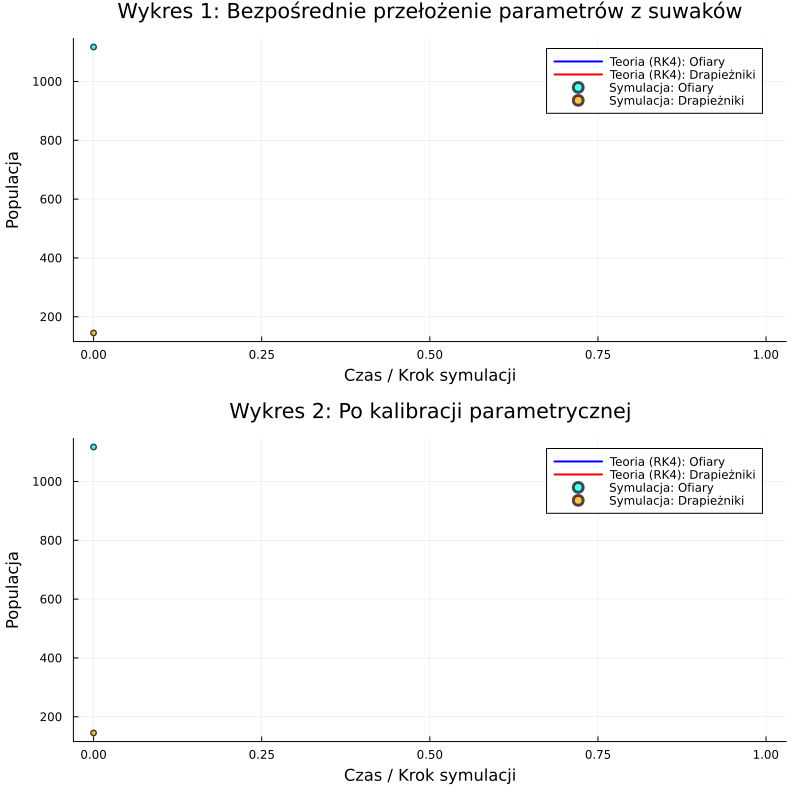

In [6]:

calibrated_parameters = calibrate_parameters(history_points_time_prey, history_points_time_pred)


r_opt, K_opt, α_opt, b_opt, d_opt = calibrated_parameters

punkty_zajace = history_points_time_prey[]
punkty_wilki  = history_points_time_pred[]

data_prey_sym = [Float64(p[2]) for p in punkty_zajace]
data_pred_sym = [Float64(p[2]) for p in punkty_wilki]
t_points = [Float64(p[1]) for p in punkty_zajace]
t_max_val = Float64(maximum(t_points))


t_points_set = Set(t_points)
rk4_res = run_rk4(calibrated_parameters, [data_prey_sym[1], data_pred_sym[1]], t_max_val, 0.1, t_points_set)


t_kalib = sort(collect(keys(rk4_res)))
prey_kalib = [rk4_res[t][1] for t in t_kalib]
pred_kalib = [rk4_res[t][2] for t in t_kalib]

r_suw = sg.sliders[3].value[]
K_suw = sg.sliders[1].value[] * 64.0
α_suw = sg.sliders[4].value[] / 64.0
d_suw = sg.sliders[5].value[]
b_suw = 0.75 * α_suw

p_suwakow = [r_suw, K_suw, α_suw, b_suw, d_suw]
rk4_suw_res = run_rk4(p_suwakow, [data_prey_sym[1], data_pred_sym[1]], t_max_val, 0.1, t_points_set)
t_suw = sort(collect(keys(rk4_suw_res)))
prey_suw = [rk4_suw_res[t][1] for t in t_suw]
pred_suw = [rk4_suw_res[t][2] for t in t_suw]

p1 = Plots.plot(t_suw, prey_suw, label="Teoria (RK4): Ofiary", color=:blue, linewidth=2)
Plots.plot!(p1, t_suw, pred_suw, label="Teoria (RK4): Drapieżniki", color=:red, linewidth=2)
Plots.scatter!(p1, t_points[1:5:end], data_prey_sym[1:5:end], label="Symulacja: Ofiary", color=:cyan, markersize=3, alpha=0.7)
Plots.scatter!(p1, t_points[1:5:end], data_pred_sym[1:5:end], label="Symulacja: Drapieżniki", color=:orange, markersize=3, alpha=0.7)
Plots.title!(p1, "Wykres 1: Bezpośrednie przełożenie parametrów z suwaków")
Plots.xlabel!(p1, "Czas / Krok symulacji")
Plots.ylabel!(p1, "Populacja")


p2 = Plots.plot(t_kalib, prey_kalib, label="Teoria (RK4): Ofiary", color=:blue, linewidth=2)
Plots.plot!(p2, t_kalib, pred_kalib, label="Teoria (RK4): Drapieżniki", color=:red, linewidth=2)
Plots.scatter!(p2, t_points[1:5:end], data_prey_sym[1:5:end], label="Symulacja: Ofiary", color=:cyan, markersize=3, alpha=0.7)
Plots.scatter!(p2, t_points[1:5:end], data_pred_sym[1:5:end], label="Symulacja: Drapieżniki", color=:orange, markersize=3, alpha=0.7)
Plots.title!(p2, "Wykres 2: Po kalibracji parametrycznej")
Plots.xlabel!(p2, "Czas / Krok symulacji")
Plots.ylabel!(p2, "Populacja")

Plots.plot(p1, p2, layout=(2,1), size=(800,800))